In [2]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats #For QQ plot
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
# Load a different dataset - Iris dataset (classification)
from sklearn.datasets import load_iris


In [22]:
# Load iris data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

In [23]:

# Select only 3 columns like your original code
df = df[['sepal length (cm)', 'petal length (cm)', 'species']]
df.columns = ['Length1', 'Length2', 'Target']  # Rename for simplicity

print("First few rows:")
print(df.sample(5))
print("\nMissing values:")
print(df.isnull().sum())


First few rows:
     Length1  Length2  Target
43       5.0      1.6       0
105      7.6      6.6       2
73       6.1      4.7       1
109      7.2      6.1       2
85       6.0      4.5       1

Missing values:
Length1    0
Length2    0
Target     0
dtype: int64


In [6]:

# Split features and target
X = df.iloc[:, :2]  # First two columns
y = df.iloc[:, 2]   # Target column

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


/tmp/ipykernel_55/1232114515.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Length1'])


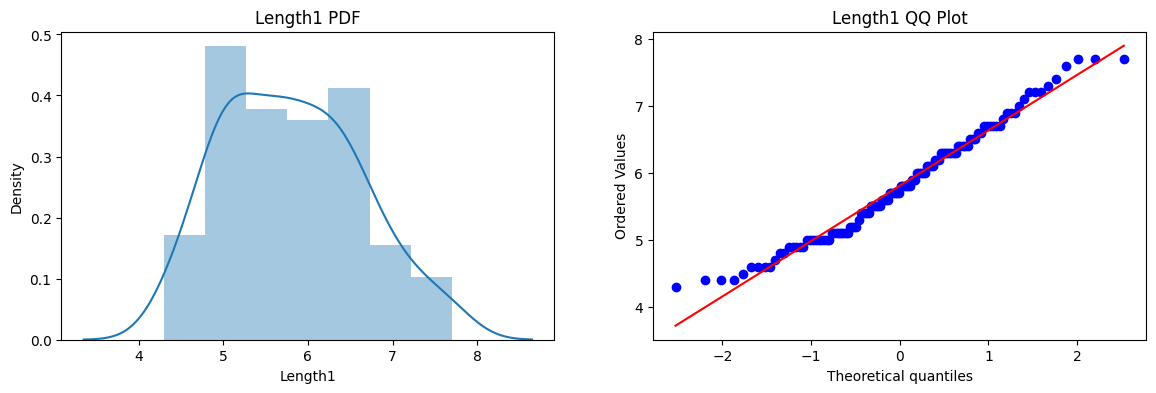

In [7]:

# Plot distributions
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Length1'])
plt.title('Length1 PDF')

plt.subplot(122)
stats.probplot(X_train['Length1'], dist="norm", plot=plt)
plt.title('Length1 QQ Plot')
plt.show()


/tmp/ipykernel_55/1616734981.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Length2'])


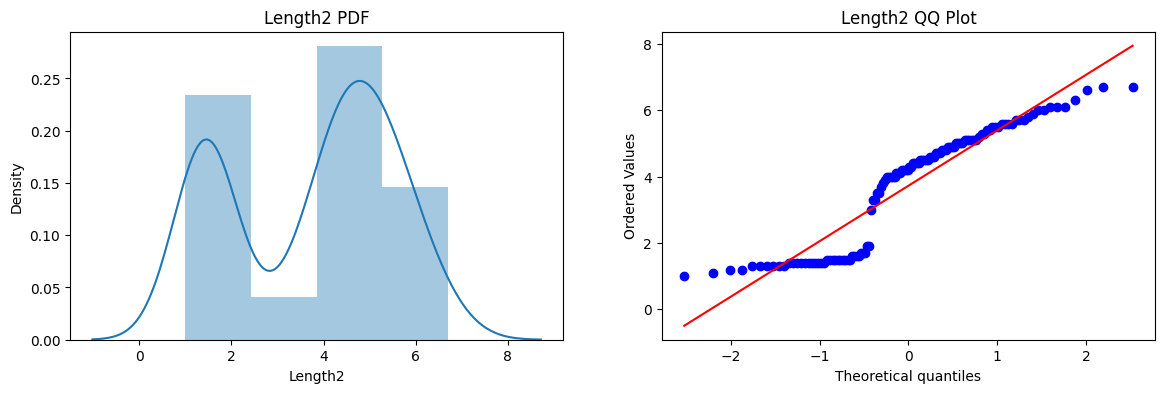

In [8]:

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Length2'])
plt.title('Length2 PDF')

plt.subplot(122)
stats.probplot(X_train['Length2'], dist="norm", plot=plt)
plt.title('Length2 QQ Plot')
plt.show()

In [9]:
# Train models without transformation
clf = LogisticRegression(max_iter=200)
clf2 = DecisionTreeClassifier()

In [10]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Without Transformation:")
print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))


Without Transformation:
Accuracy LR 1.0
Accuracy DT 0.9666666666666667


In [11]:

# Apply log transformation to all features
trf = FunctionTransformer(func=np.log1p)
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)


In [24]:
# Convert to numpy arrays for indexing
X_train_transformed_np = np.array(X_train_transformed)
X_test_transformed_np = np.array(X_test_transformed)
X_test_transformed_np

array([[1.96009478, 1.74046617],
       [1.90210753, 0.99325177],
       [2.16332303, 2.06686276],
       [1.94591015, 1.70474809],
       [2.05412373, 1.75785792],
       [1.85629799, 0.91629073],
       [1.88706965, 1.5260563 ],
       [2.06686276, 1.80828877],
       [1.97408103, 1.70474809],
       [1.91692261, 1.58923521],
       [2.01490302, 1.80828877],
       [1.75785792, 0.87546874],
       [1.87180218, 0.83290912],
       [1.77495235, 0.91629073],
       [1.80828877, 0.91629073],
       [1.98787435, 1.74046617],
       [2.01490302, 1.91692261],
       [1.88706965, 1.58923521],
       [1.90210753, 1.70474809],
       [2.00148   , 1.88706965],
       [1.74046617, 0.95551145],
       [1.96009478, 1.77495235],
       [1.79175947, 0.95551145],
       [2.00148   , 1.88706965],
       [2.18605128, 2.00148   ],
       [2.04122033, 1.82454929],
       [2.04122033, 1.91692261],
       [2.05412373, 1.93152141],
       [1.75785792, 0.87546874],
       [1.75785792, 0.95551145]])

In [13]:
clf = LogisticRegression(max_iter=200)
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("\nWith Log Transformation (all features):")
print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))


With Log Transformation (all features):
Accuracy LR 0.9333333333333333
Accuracy DT 1.0


In [14]:
# Cross-validation with transformed data
X_transformed = trf.fit_transform(X)

clf = LogisticRegression(max_iter=200)
clf2 = DecisionTreeClassifier()

print("\nCross-validation scores:")
print("LR", np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_transformed, y, scoring='accuracy', cv=10)))



Cross-validation scores:
LR 0.9066666666666666
DT 0.9400000000000001


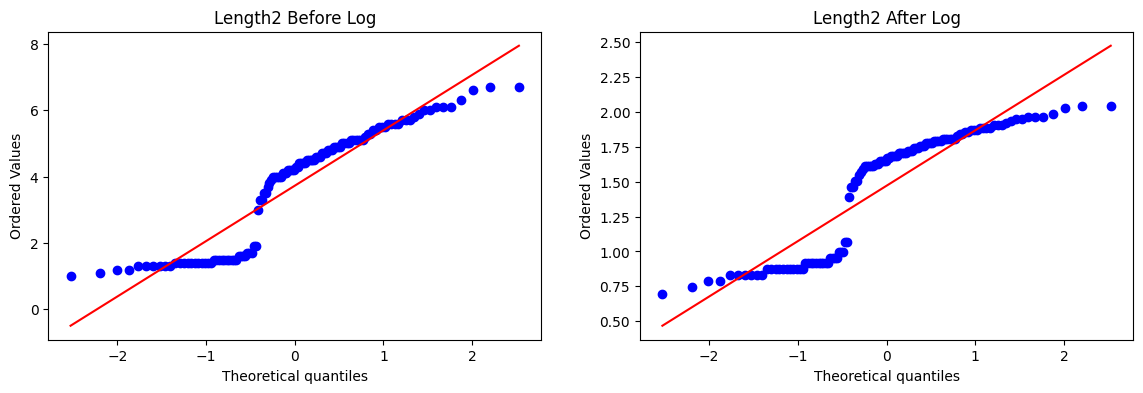

In [15]:

# QQ plots before and after transformation
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Length2'], dist="norm", plot=plt)
plt.title('Length2 Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed.iloc[:, 1], dist="norm", plot=plt)
plt.title('Length2 After Log')
plt.show()

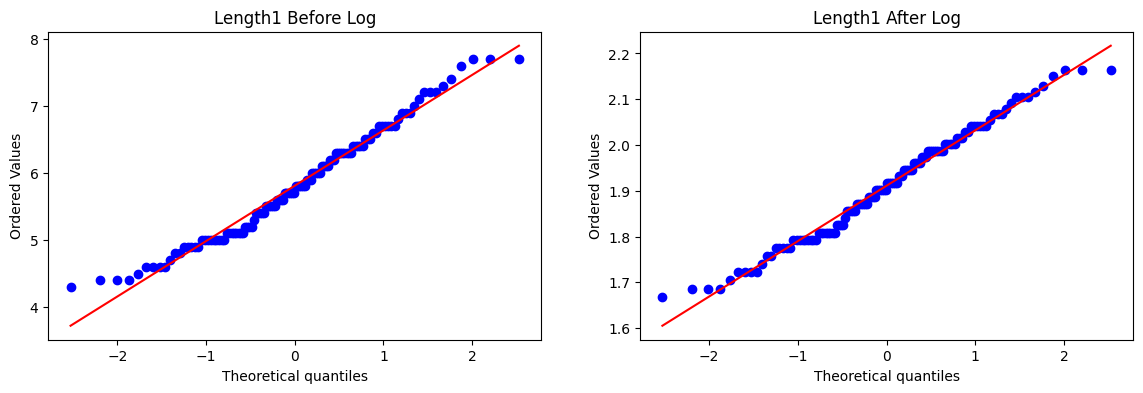

In [17]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Length1'], dist="norm", plot=plt)
plt.title('Length1 Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed.iloc[:, 0], dist="norm", plot=plt)
plt.title('Length1 After Log')
plt.show()

In [18]:
# Apply transformation to only one column (like your Fare column)
trf2 = ColumnTransformer([
    ('log', FunctionTransformer(np.log1p), [1])  # Transform only second column
], remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

clf = LogisticRegression(max_iter=200)
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("\nWith Transformation (only second column):")
print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred2))

# Cross-validation with column-specific transformation
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression(max_iter=200)
clf2 = DecisionTreeClassifier()

print("\nCross-validation with column-specific transform:")
print("LR", np.mean(cross_val_score(clf, X_transformed2, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_transformed2, y, scoring='accuracy', cv=10)))



With Transformation (only second column):
Accuracy LR 0.9
Accuracy DT 1.0

Cross-validation with column-specific transform:
LR 0.8333333333333334
DT 0.9466666666666667


In [19]:
# Function to test different transformations (like your apply_transform)
def apply_transform(transform):
    X = df.iloc[:, :2]
    y = df.iloc[:, 2]
    
    trf = ColumnTransformer([
        ('log', FunctionTransformer(transform), [1])  # Transform second column
    ], remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression(max_iter=200)
    
    print("\nAccuracy with", transform.__name__, 
          np.mean(cross_val_score(clf, X_trans, y, scoring='accuracy', cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Length2'], dist="norm", plot=plt)
    plt.title('Length2 Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Length2 After Transform')
    plt.show()



Testing different transformations

Accuracy with log1p 0.8333333333333334


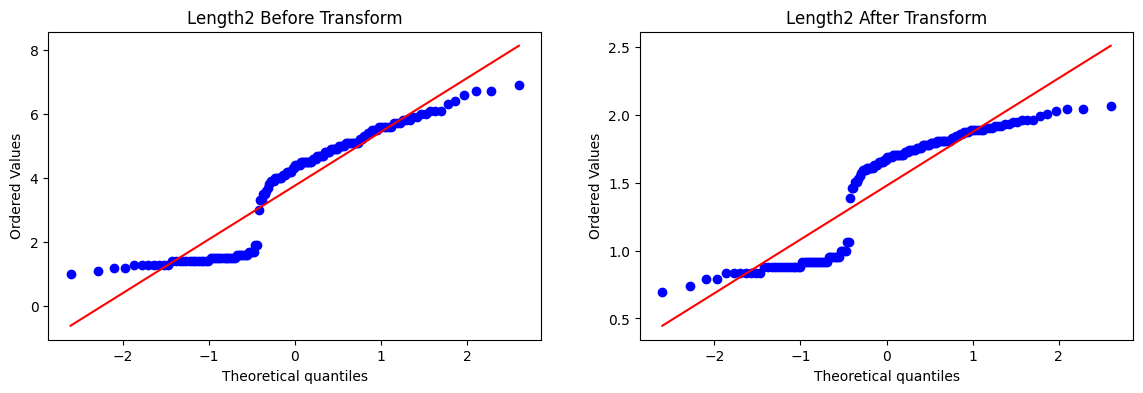


Accuracy with sqrt 0.8333333333333334


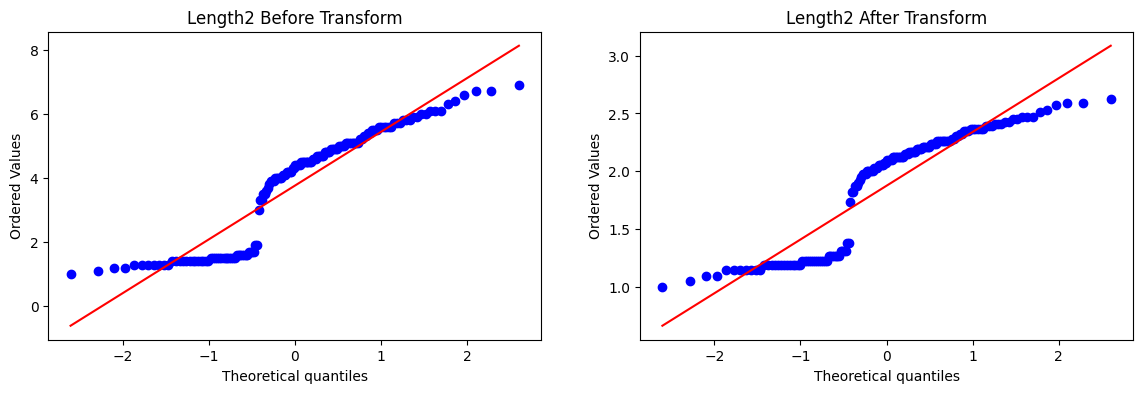


Accuracy with sin 0.8133333333333332


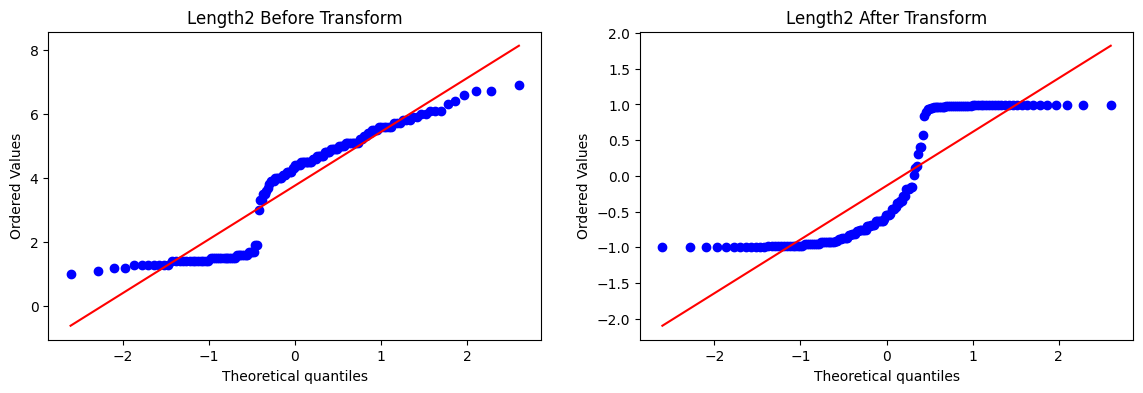

In [20]:

# Test different transformations
print("\n" + "="*50)
print("Testing different transformations")
print("="*50)

apply_transform(np.log1p)  # log transform
apply_transform(np.sqrt)    # square root
apply_transform(np.sin)     # sine (like your example)